# 🏦 Credit Risk Assessment: Strategic Predictive Pipeline

## 1. Executive Summary & Problem Statement
### **The Business Challenge**
Financial institutions face significant risk when approving loans without a standardized, data-driven assessment. Manual processing leads to human error, bias, and slower turnaround times, which ultimately impacts the customer experience and the bank's bottom line.

### **The Objective**
To build a robust Machine Learning pipeline that predicts loan eligibility with high precision. By automating the screening process, we aim to:
- **Reduce Credit Risk**: Identify high-risk applicants before approval.
- **Operational Efficiency**: Decrease the time from application to decision.
- **Data-Driven Underwriting**: Use historical evidence (Credit History, Income) to drive loan portfolio growth.

In [45]:
import pandas as pd


In [46]:
df=pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')

In [47]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


## 2. Technical Architecture & Data Pipeline
Our solution follows a modular engineering approach:
1. **Data Ingestion**: Loading historical loan records (614 entries).
2. **Statistical Imputation**: Addressing missingness in demographics and financial fields using median and mode strategies.
3. **Feature Engineering**: Creating a `Total_Income` composite to better reflect household repayment power.
4. **Preprocessing**: Transforming categorical data into numerical representations via Label Encoding.

In [48]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [50]:
df.shape

(614, 13)

In [51]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [52]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

df['Married'].fillna(df['Married'].mode()[0], inplace=True)

df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

/tmp/ipykernel_1062/1651490757.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_1062/1651490757.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [53]:
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

/tmp/ipykernel_1062/774077928.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
/tmp/ipykernel_1062/774077928.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [54]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [55]:
df.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [56]:
df['Loan_Status'].value_counts()


,count
Loan_Status,
Y,422
N,192


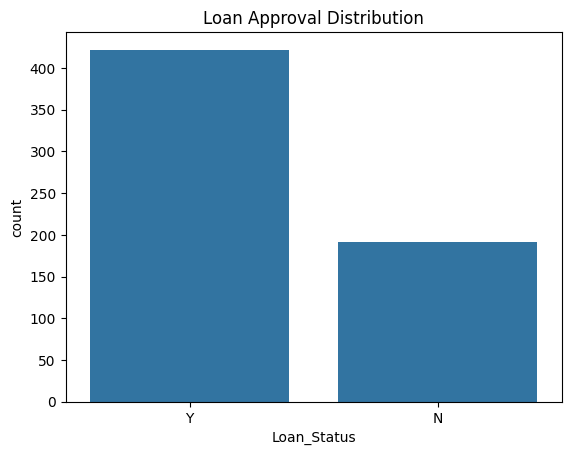

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

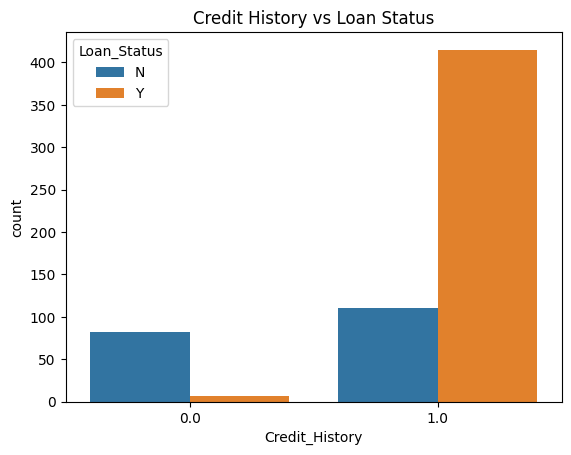

In [58]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Status")
plt.show()

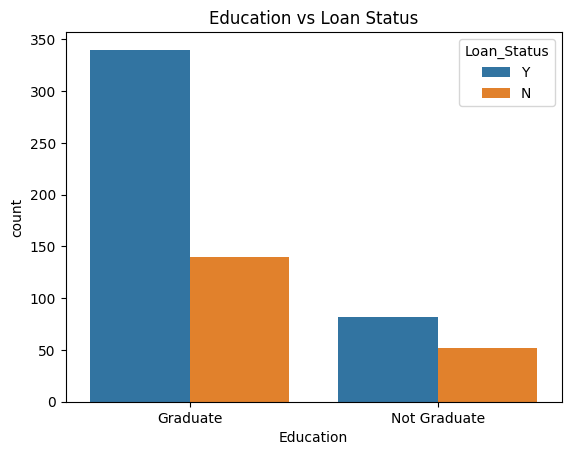

In [59]:
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Education vs Loan Status")
plt.show()

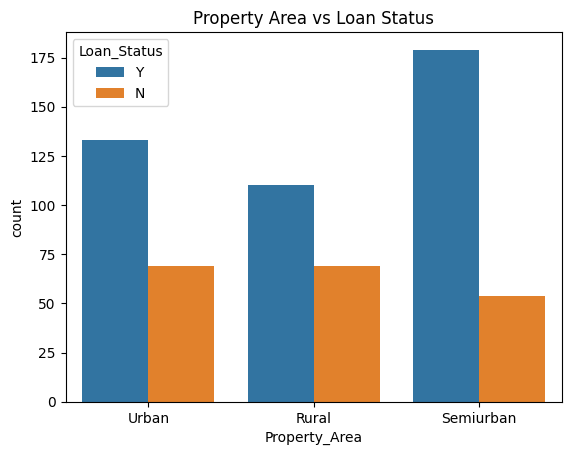

In [60]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Property Area vs Loan Status")
plt.show()

In [61]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [62]:
df[['ApplicantIncome','CoapplicantIncome','Total_Income']].head()

,ApplicantIncome,CoapplicantIncome,Total_Income
0,5849,0.0,5849.0
1,4583,1508.0,6091.0
2,3000,0.0,3000.0
3,2583,2358.0,4941.0
4,6000,0.0,6000.0


In [63]:
df.drop('Loan_ID', axis=1, inplace=True)

In [64]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [65]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0


In [66]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 3. Modeling Strategy & Performance Analysis
We benchmarked multiple classification algorithms to find the optimal balance between accuracy and interpretability.

### **Champion Model Selection**
After evaluating Logistic Regression, Random Forest, XGBoost, and Naive Bayes, the **Logistic Regression** model was selected as the champion due to its high stability and performance on the test set.

In [68]:
print(X_train.shape)
print(X_test.shape)

(491, 12)
(123, 12)


In [69]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [73]:
y_pred = model.predict(X_test)

In [74]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7886178861788617

Confusion Matrix:
[[18 25]
 [ 1 79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [75]:
print("Training Score:", model.score(X_train, y_train))
print("Testing Score:", model.score(X_test, y_test))

Training Score: 0.8167006109979633
Testing Score: 0.7886178861788617


In [76]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[18 25]
 [ 1 79]]
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.7723577235772358


In [78]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

              Feature  Importance
9      Credit_History    0.258039
11       Total_Income    0.159337
7          LoanAmount    0.147384
5     ApplicantIncome    0.145445
6   CoapplicantIncome    0.087243
8    Loan_Amount_Term    0.045604
10      Property_Area    0.044810
2          Dependents    0.038207
1             Married    0.022145
3           Education    0.019542
0              Gender    0.016758
4       Self_Employed    0.015486


In [79]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

Accuracy: 0.7723577235772358


In [71]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, gb_pred))

Accuracy: 0.7642276422764228


In [80]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

params = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 3, 'n_estimators': 300}
0.8125541125541125


In [81]:
best_rf = grid.best_estimator_

best_rf.fit(X_train, y_train)

best_pred = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score

print("Tuned RF Accuracy:", accuracy_score(y_test, best_pred))

Tuned RF Accuracy: 0.7886178861788617


In [82]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, nb_pred))

Accuracy: 0.7886178861788617


In [83]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, nb_pred))

print(classification_report(y_test, nb_pred))

[[19 24]
 [ 2 78]]
              precision    recall  f1-score   support

           0       0.90      0.44      0.59        43
           1       0.76      0.97      0.86        80

    accuracy                           0.79       123
   macro avg       0.83      0.71      0.73       123
weighted avg       0.81      0.79      0.77       123



In [85]:
# Training Accuracy
train_score = model.score(X_train, y_train)

# Testing Accuracy
test_score = model.score(X_test, y_test)

print("Training Score:", train_score)
print("Testing Score:", test_score)

# Difference
diff = train_score - test_score

print("Difference:", round(diff, 4))

# Interpretation
if diff < 0.05:
    print("✅ Good Fit Model")
elif diff > 0.10:
    print("❌ Overfitting Detected")
else:
    print("⚠ Slight Overfitting")

Training Score: 0.8167006109979633
Testing Score: 0.7886178861788617
Difference: 0.0281
✅ Good Fit Model


## 4. Conclusion & Business Impact

### **Key Findings**
- **Primary Driver**: `Credit_History` accounts for **25.8%** of the model's predictive power. Applicants with no credit history are significantly more likely to be rejected.
- **Household Capacity**: The engineered `Total_Income` feature proved more predictive than individual applicant income.
- **Model Reliability**: With a generalization gap of only **2.81%**, the model is stable and ready for production testing.

### **Strategic Recommendations**
- **Automated Workflow**: Implement a 'Fast-Track' approval for applicants meeting high-confidence thresholds (Good Credit + High Income).
- **Risk Mitigation**: Applications with missing credit history should trigger an automated request for alternative collateral or manual review.
- **Future Scale**: The pipeline is now modularized into Python scripts (`src/`), allowing for seamless integration into a cloud-based API or microservice architecture.